In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_RAW     :", DATA_RAW)

PROJECT_ROOT : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations
DATA_RAW     : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/raw


In [3]:
sirh_path = DATA_RAW / "extrait_sirh.csv"
eval_path = DATA_RAW / "extrait_eval.csv"
survey_path = DATA_RAW / "extrait_sondage.csv"

df_sirh = pd.read_csv(sirh_path)
df_eval = pd.read_csv(eval_path)
df_survey = pd.read_csv(survey_path)

In [4]:
def inspect_df(df: pd.DataFrame, name: str) -> None:
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("Shape :", df.shape)
    print("\nColonnes :")
    print(df.columns.tolist())
    print("\nTypes :")
    print(df.dtypes)
    print("\nValeurs manquantes :")
    print(df.isna().sum().sort_values(ascending=False).head(20))
    print("\nDoublons :", df.duplicated().sum())
    display(df.head())

In [5]:
inspect_df(df_sirh, "SIRH")
inspect_df(df_eval, "ÉVALUATIONS")
inspect_df(df_survey, "SONDAGE")

SIRH
Shape : (1470, 12)

Colonnes :
['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']

Types :
id_employee                       int64
age                               int64
genre                               str
revenu_mensuel                    int64
statut_marital                      str
departement                         str
poste                               str
nombre_experiences_precedentes    int64
nombre_heures_travailless         int64
annee_experience_totale           int64
annees_dans_l_entreprise          int64
annees_dans_le_poste_actuel       int64
dtype: object

Valeurs manquantes :
id_employee                       0
age                               0
genre                             0
revenu_mensuel                    0
statut_marital                    0
departement       

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


ÉVALUATIONS
Shape : (1470, 10)

Colonnes :
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']

Types :
satisfaction_employee_environnement          int64
note_evaluation_precedente                   int64
niveau_hierarchique_poste                    int64
satisfaction_employee_nature_travail         int64
satisfaction_employee_equipe                 int64
satisfaction_employee_equilibre_pro_perso    int64
eval_number                                    str
note_evaluation_actuelle                     int64
heure_supplementaires                          str
augementation_salaire_precedente               str
dtype: object

Valeurs manquantes :
satisfaction_employee_environnement          0
note_evaluation_precedente         

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


SONDAGE
Shape : (1470, 12)

Colonnes :
['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']

Types :
a_quitte_l_entreprise                    str
nombre_participation_pee               int64
nb_formations_suivies                  int64
nombre_employee_sous_responsabilite    int64
code_sondage                           int64
distance_domicile_travail              int64
niveau_education                       int64
domaine_etude                            str
ayant_enfants                            str
frequence_deplacement                    str
annees_depuis_la_derniere_promotion    int64
annes_sous_responsable_actuel          int64
dtype: object

Valeurs manquantes :
a_quitte_l_entreprise                  0
nombre_participation_

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


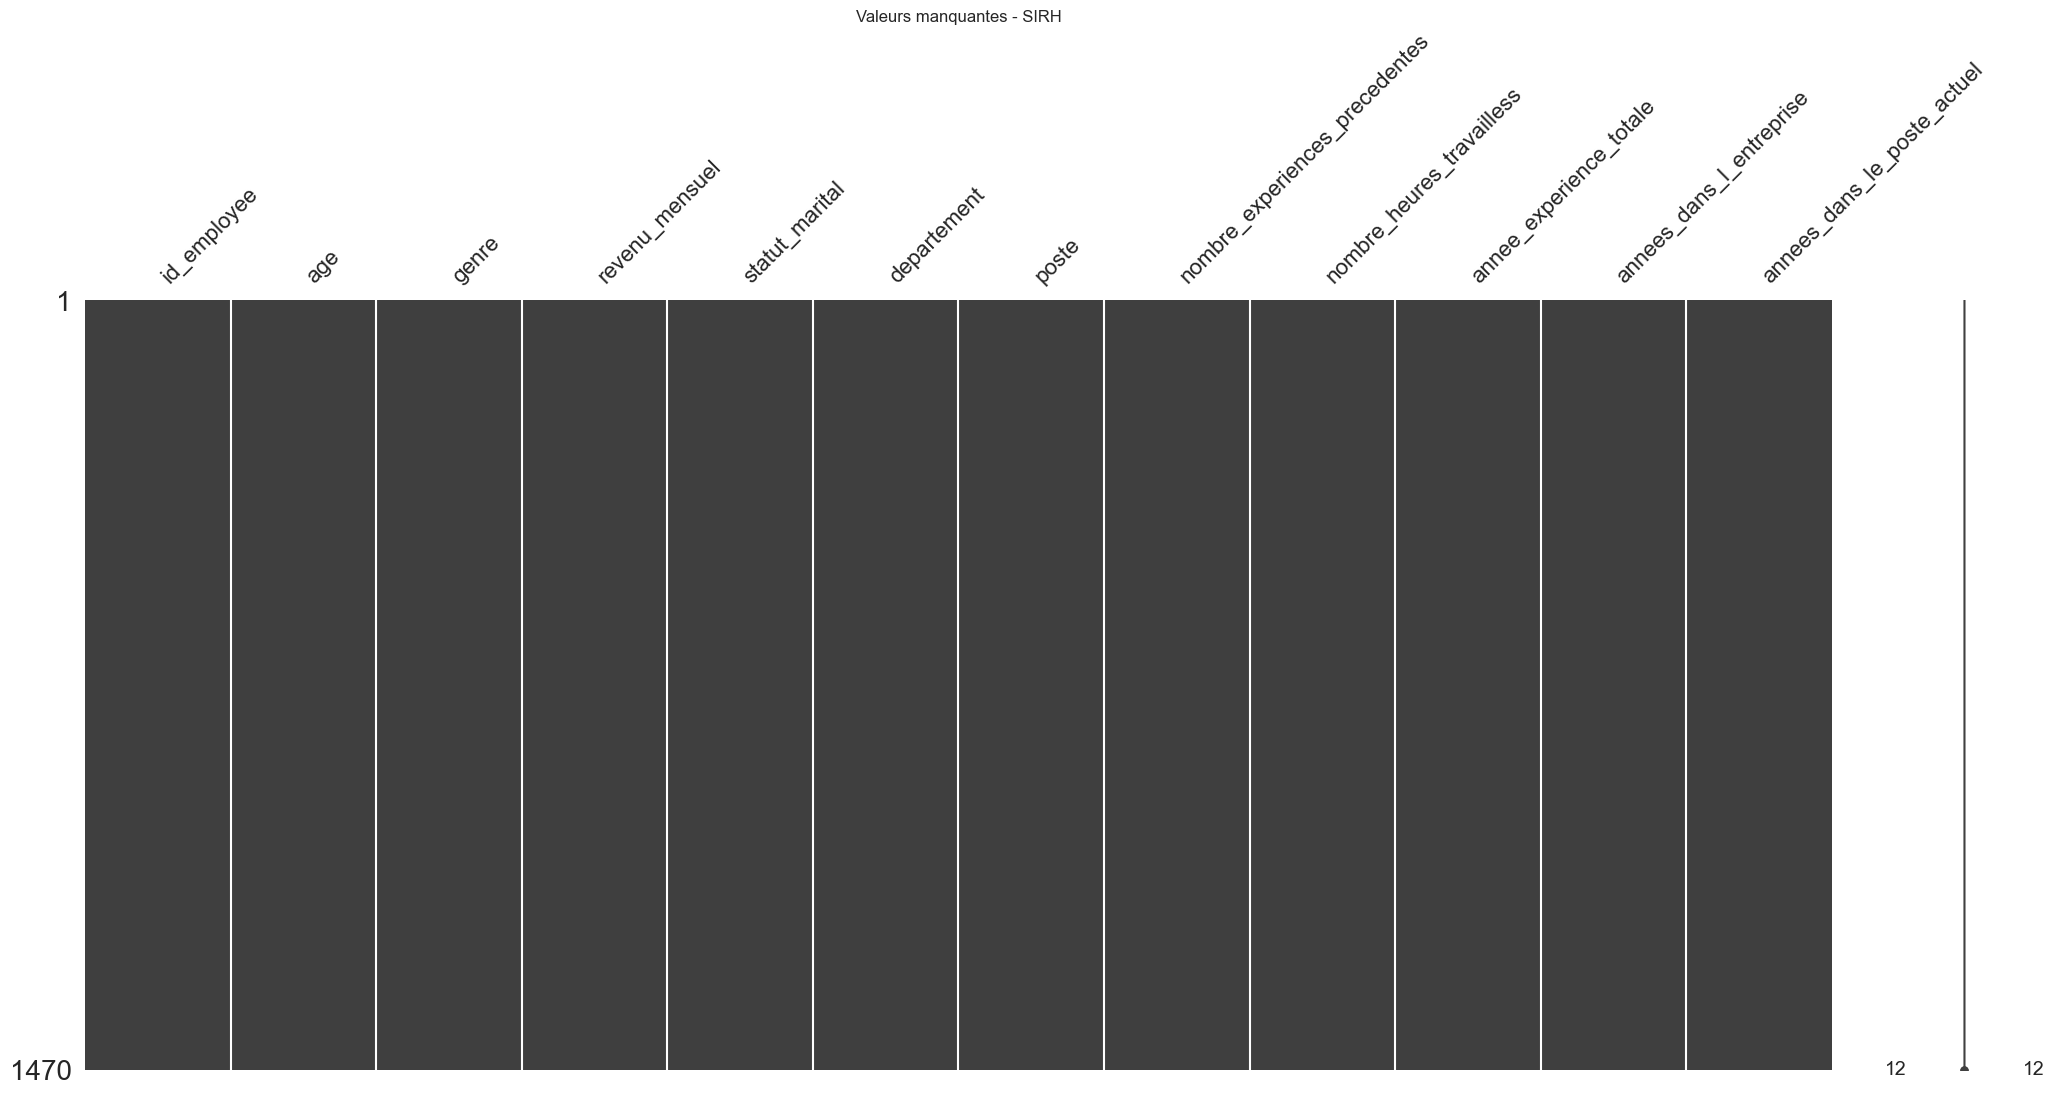

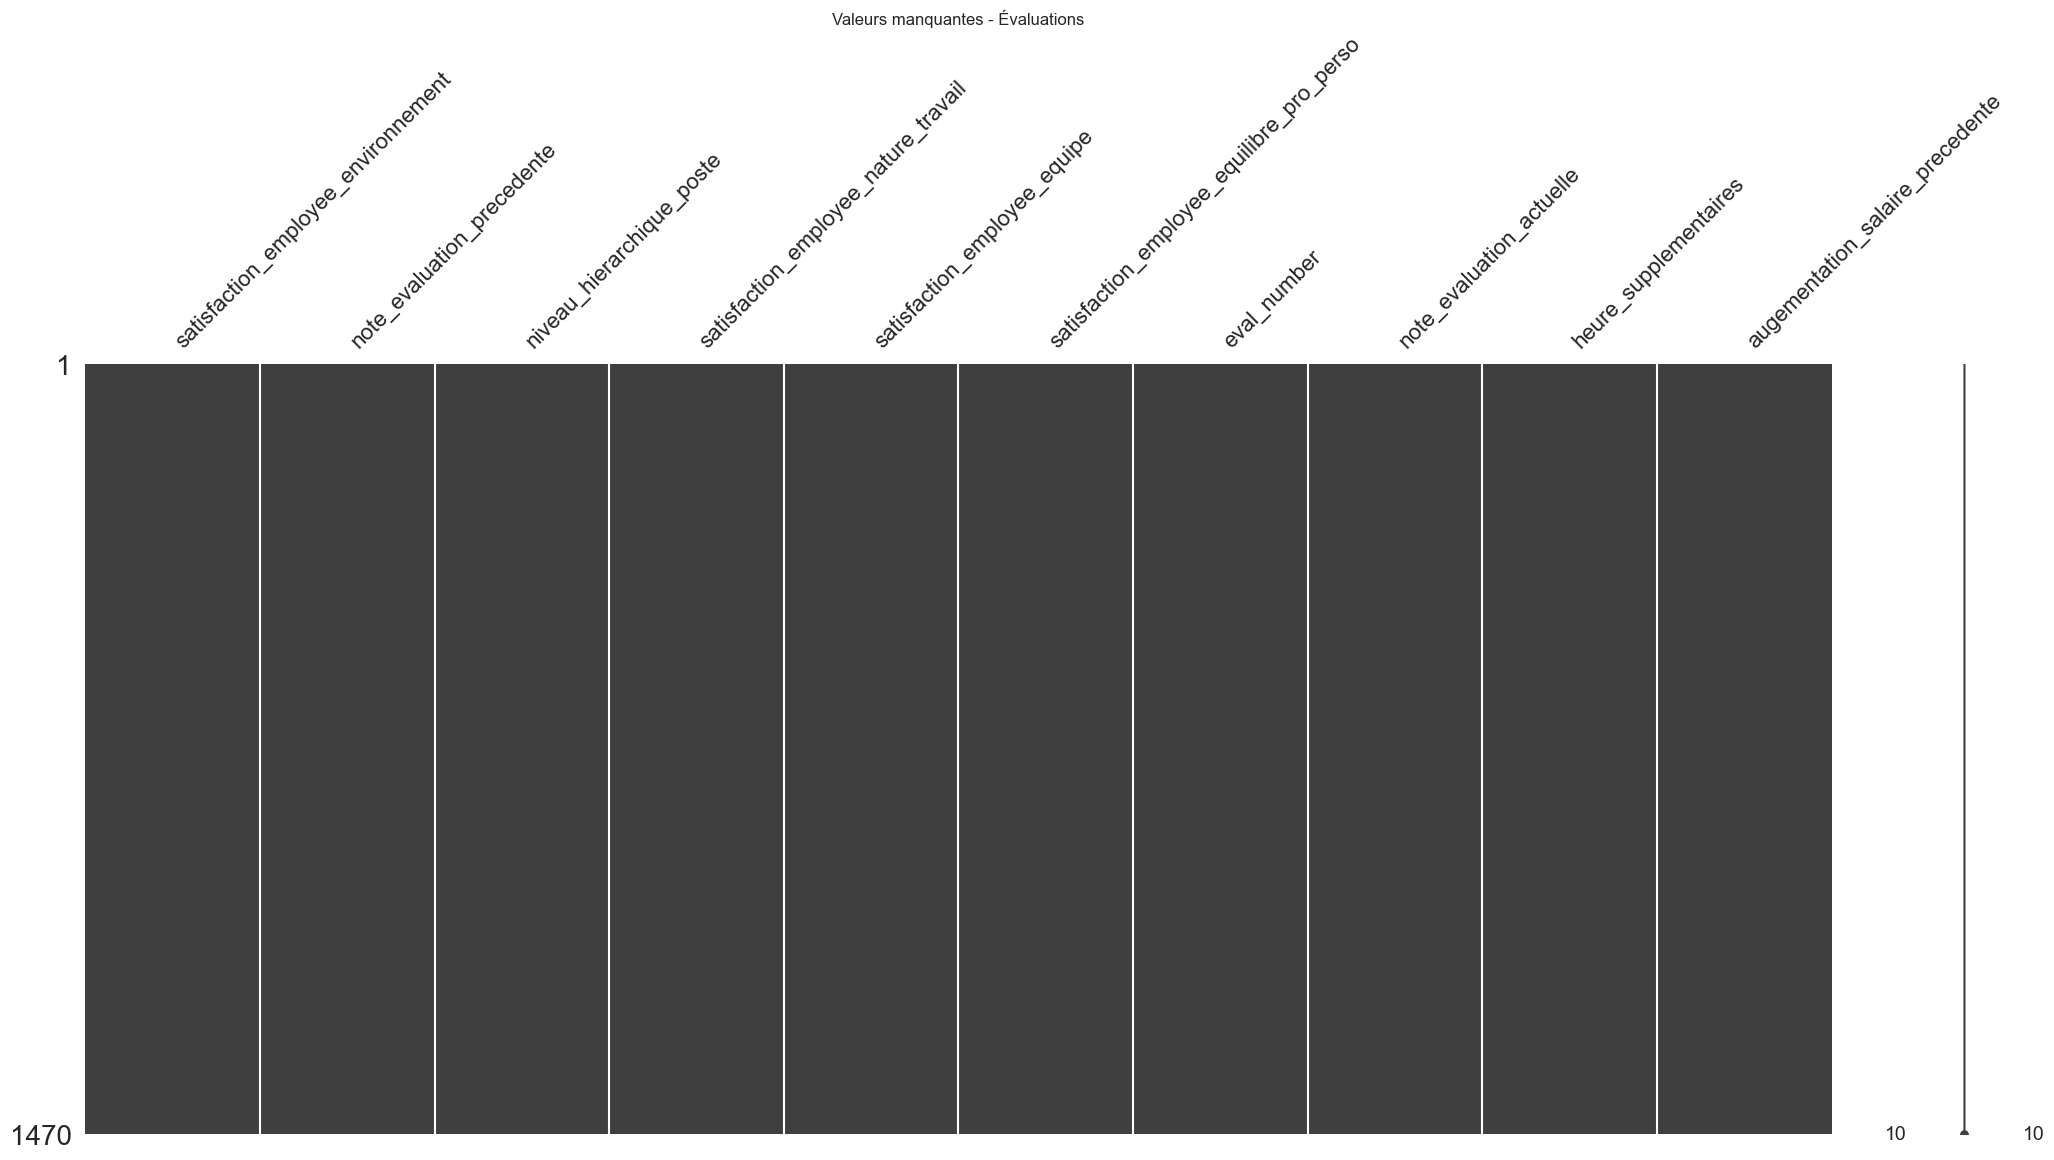

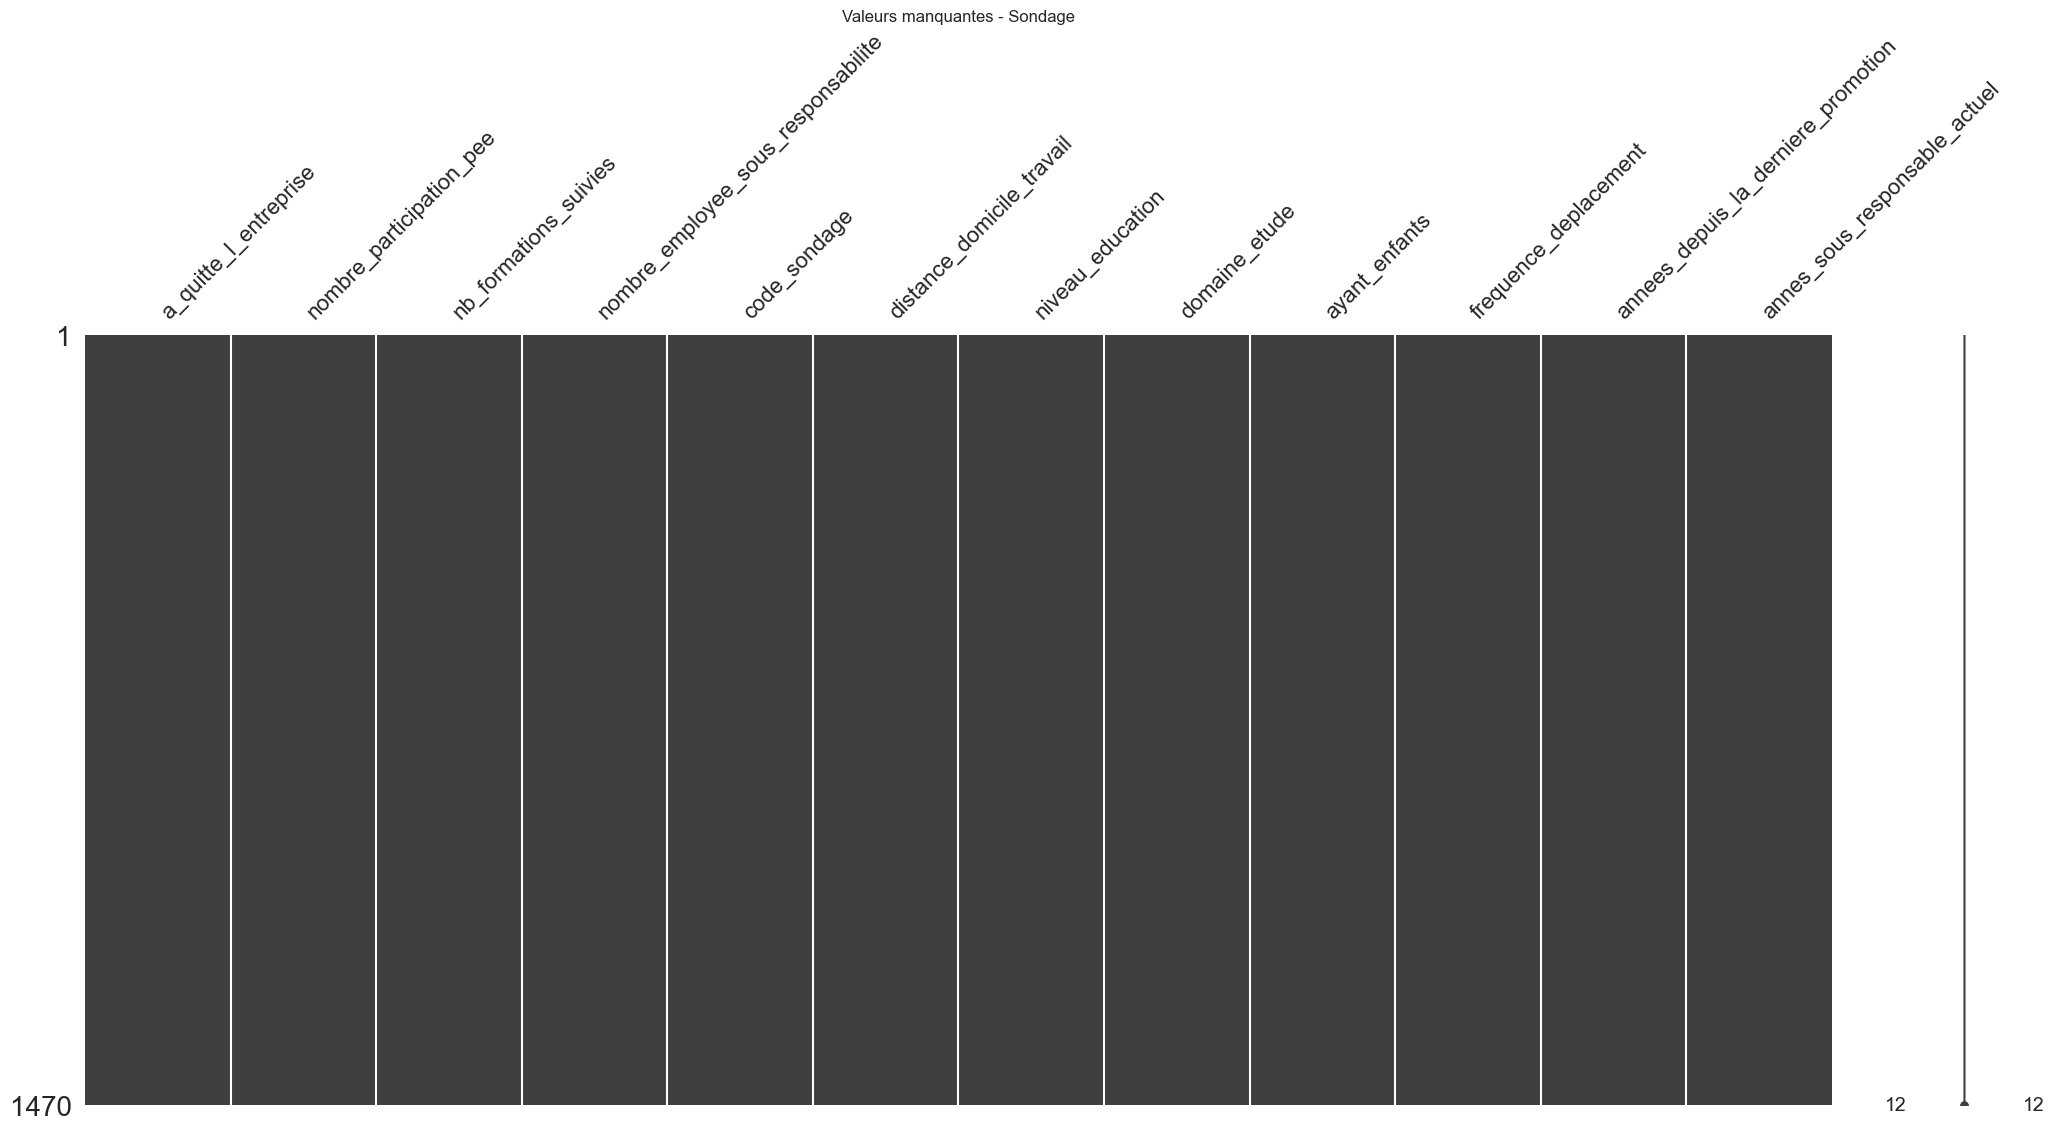

In [6]:
msno.matrix(df_sirh)
plt.title("Valeurs manquantes - SIRH")
plt.show()

msno.matrix(df_eval)
plt.title("Valeurs manquantes - Évaluations")
plt.show()

msno.matrix(df_survey)
plt.title("Valeurs manquantes - Sondage")
plt.show()

In [7]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("é", "e", regex=False)
        .str.replace("è", "e", regex=False)
        .str.replace("ê", "e", regex=False)
        .str.replace("à", "a", regex=False)
        .str.replace("ç", "c", regex=False)
        .str.replace(r"[^a-z0-9_]", "", regex=True)
    )
    return df

df_sirh = clean_columns(df_sirh)
df_eval = clean_columns(df_eval)
df_survey = clean_columns(df_survey)

print(df_sirh.columns.tolist())
print(df_eval.columns.tolist())
print(df_survey.columns.tolist())

['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']
['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


In [8]:
print("SIRH")
print(df_sirh.columns.tolist())

print("\nEVAL")
print(df_eval.columns.tolist())

print("\nSURVEY")
print(df_survey.columns.tolist())

SIRH
['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']

EVAL
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']

SURVEY
['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


In [9]:
common_sirh_eval = set(df_sirh.columns).intersection(df_eval.columns)
common_sirh_survey = set(df_sirh.columns).intersection(df_survey.columns)
common_eval_survey = set(df_eval.columns).intersection(df_survey.columns)

print("Colonnes communes SIRH / EVAL :", common_sirh_eval)
print("Colonnes communes SIRH / SURVEY :", common_sirh_survey)
print("Colonnes communes EVAL / SURVEY :", common_eval_survey)

Colonnes communes SIRH / EVAL : set()
Colonnes communes SIRH / SURVEY : set()
Colonnes communes EVAL / SURVEY : set()


In [10]:
for name, df in {
    "SIRH": df_sirh,
    "EVAL": df_eval,
    "SURVEY": df_survey
}.items():
    print(f"\n{name}")
    for col in df.columns:
        if "id" in col.lower() or "matric" in col.lower() or "employ" in col.lower() or "collab" in col.lower():
            print(col)


SIRH
id_employee

EVAL
satisfaction_employee_environnement
satisfaction_employee_nature_travail
satisfaction_employee_equipe
satisfaction_employee_equilibre_pro_perso

SURVEY
nombre_employee_sous_responsabilite


In [11]:
print ("Colonnes communes aux 3 fichiers :")
common_all = set (df_sirh.columns).intersection (df_eval.columns).intersection (df_survey.columns)
print (common_all)

print ("\nColonnes qui ressemblent à une clé :")
for col in sorted (common_all):
    if any (token in col.lower ( ) for token in ["id", "matric", "employ", "collab"]):
        print (col)

Colonnes communes aux 3 fichiers :
set()

Colonnes qui ressemblent à une clé :


In [12]:
common_all = set (df_sirh.columns).intersection (df_eval.columns).intersection (df_survey.columns)

candidate_keys = [
    col for col in sorted (common_all)
    if any (token in col.lower ( ) for token in ["id", "matric", "employ", "collab"])
]

print ("Colonnes communes aux 3 fichiers :", common_all)
print ("Candidates de clé :", candidate_keys)

if len (candidate_keys) == 1:
    key = candidate_keys[0]
    print (f"\nClé probable retenue : {key}")
    print (df_sirh[key].nunique ( ), df_sirh.shape[0])
    print (df_eval[key].nunique ( ), df_eval.shape[0])
    print (df_survey[key].nunique ( ), df_survey.shape[0])
else:
    print ("\nAucune clé unique évidente trouvée automatiquement.")
    print ("Vérifiez manuellement les colonnes affichées ci-dessus.")

Colonnes communes aux 3 fichiers : set()
Candidates de clé : []

Aucune clé unique évidente trouvée automatiquement.
Vérifiez manuellement les colonnes affichées ci-dessus.


In [13]:
for name, df in {
    "SIRH": df_sirh,
    "EVAL": df_eval,
    "SURVEY": df_survey
}.items ( ):
    print (f"\n{'=' * 80}\n{name}\n{'=' * 80}")
    for col in df.columns:
        if any (token in col.lower ( ) for token in [
            "id", "matric", "employ", "collab", "salar", "person", "agent"
        ]):
            print (col)


SIRH
id_employee

EVAL
satisfaction_employee_environnement
satisfaction_employee_nature_travail
satisfaction_employee_equipe
satisfaction_employee_equilibre_pro_perso

SURVEY
nombre_employee_sous_responsabilite


In [14]:
for name, df in {
    "SIRH": df_sirh,
    "EVAL": df_eval,
    "SURVEY": df_survey
}.items ( ):
    print (f"\n{'=' * 80}\n{name}\n{'=' * 80}")
    for col in df.columns:
        print (col)


SIRH
id_employee
age
genre
revenu_mensuel
statut_marital
departement
poste
nombre_experiences_precedentes
nombre_heures_travailless
annee_experience_totale
annees_dans_l_entreprise
annees_dans_le_poste_actuel

EVAL
satisfaction_employee_environnement
note_evaluation_precedente
niveau_hierarchique_poste
satisfaction_employee_nature_travail
satisfaction_employee_equipe
satisfaction_employee_equilibre_pro_perso
eval_number
note_evaluation_actuelle
heure_supplementaires
augementation_salaire_precedente

SURVEY
a_quitte_l_entreprise
nombre_participation_pee
nb_formations_suivies
nombre_employee_sous_responsabilite
code_sondage
distance_domicile_travail
niveau_education
domaine_etude
ayant_enfants
frequence_deplacement
annees_depuis_la_derniere_promotion
annes_sous_responsable_actuel


In [15]:
sirh_cols = set (df_sirh.columns)
eval_cols = set (df_eval.columns)
survey_cols = set (df_survey.columns)

print ("Présentes seulement dans SIRH :")
print (sorted (sirh_cols - eval_cols - survey_cols))

print ("\nPrésentes seulement dans EVAL :")
print (sorted (eval_cols - sirh_cols - survey_cols))

print ("\nPrésentes seulement dans SURVEY :")
print (sorted (survey_cols - sirh_cols - eval_cols))

Présentes seulement dans SIRH :
['age', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'departement', 'genre', 'id_employee', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'poste', 'revenu_mensuel', 'statut_marital']

Présentes seulement dans EVAL :
['augementation_salaire_precedente', 'eval_number', 'heure_supplementaires', 'niveau_hierarchique_poste', 'note_evaluation_actuelle', 'note_evaluation_precedente', 'satisfaction_employee_environnement', 'satisfaction_employee_equilibre_pro_perso', 'satisfaction_employee_equipe', 'satisfaction_employee_nature_travail']

Présentes seulement dans SURVEY :
['a_quitte_l_entreprise', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'ayant_enfants', 'code_sondage', 'distance_domicile_travail', 'domaine_etude', 'frequence_deplacement', 'nb_formations_suivies', 'niveau_education', 'nombre_employee_sous_responsabilite', 'nombre_participation_pee']


In [16]:
print ("Shapes")
print ("SIRH  :", df_sirh.shape)
print ("EVAL  :", df_eval.shape)
print ("SURVEY:", df_survey.shape)

Shapes
SIRH  : (1470, 12)
EVAL  : (1470, 10)
SURVEY: (1470, 12)


In [17]:
print ("Doublons id_employee dans SIRH :", df_sirh["id_employee"].duplicated ( ).sum ( ))
print ("Valeurs manquantes id_employee dans SIRH :", df_sirh["id_employee"].isna ( ).sum ( ))

df_sirh = df_sirh.reset_index (drop=True)
df_eval = df_eval.reset_index (drop=True)
df_survey = df_survey.reset_index (drop=True)

df_central = pd.concat ([df_sirh, df_eval, df_survey], axis=1)

print ("Shape df_central :", df_central.shape)
display (df_central.head ( ))

Doublons id_employee dans SIRH : 0
Valeurs manquantes id_employee dans SIRH : 0
Shape df_central : (1470, 34)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,E_1,3,Oui,11 %,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,E_2,4,Non,23 %,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,E_4,3,Oui,15 %,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,E_5,3,Oui,11 %,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,E_7,3,Non,12 %,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [18]:
print ("Colonnes dupliquées :", df_central.columns[df_central.columns.duplicated ( )].tolist ( ))
print ("Répartition de la cible :")
print (df_central["a_quitte_l_entreprise"].value_counts (dropna=False))
print (df_central["a_quitte_l_entreprise"].value_counts (normalize=True, dropna=False))

Colonnes dupliquées : []
Répartition de la cible :
a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64
a_quitte_l_entreprise
Non    0.838776
Oui    0.161224
Name: proportion, dtype: float64


Les trois fichiers ne partagent pas de clé de jointure explicite commune. En revanche, ils présentent le même nombre de lignes (1470), ce qui suggère un alignement ligne à ligne entre les sources. Le DataFrame central a donc été construit par concaténation horizontale après réinitialisation des index.

In [19]:
df_central["a_quitte_l_entreprise"] = (
    df_central["a_quitte_l_entreprise"]
    .astype (str)
    .str.strip ( )
    .str.capitalize ( )
)

print (df_central["a_quitte_l_entreprise"].value_counts (dropna=False))

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64


In [20]:
df_central["attrition_bin"] = df_central["a_quitte_l_entreprise"].apply (
    lambda x: 1 if x == "Oui" else 0
)

print (df_central["attrition_bin"].value_counts ( ))

attrition_bin
0    1233
1     237
Name: count, dtype: int64


In [21]:
print (df_central.dtypes.sort_index ( ))

a_quitte_l_entreprise                          str
age                                          int64
annee_experience_totale                      int64
annees_dans_l_entreprise                     int64
annees_dans_le_poste_actuel                  int64
annees_depuis_la_derniere_promotion          int64
annes_sous_responsable_actuel                int64
attrition_bin                                int64
augementation_salaire_precedente               str
ayant_enfants                                  str
code_sondage                                 int64
departement                                    str
distance_domicile_travail                    int64
domaine_etude                                  str
eval_number                                    str
frequence_deplacement                          str
genre                                          str
heure_supplementaires                          str
id_employee                                  int64
nb_formations_suivies          

In [22]:
num_cols = df_central.select_dtypes (include=["number"]).columns.tolist ( )
cat_cols = df_central.select_dtypes (include=["object", "category"]).columns.tolist ( )

print ("Colonnes numériques :")
print (num_cols)

print ("\nColonnes catégorielles :")
print (cat_cols)

Colonnes numériques :
['id_employee', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'attrition_bin']

Colonnes catégorielles :
['genre', 'statut_marital', 'departement', 'poste', 'eval_number', 'heure_supplementaires', 'augementation_salaire_precedente', 'a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement']


/var/folders/6s/mlpq3tkd2197ztqzbkb3ql0r0000gn/T/ipykernel_44366/1142415675.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_central.select_dtypes (include=["object", "category"]).columns.tolist ( )


In [23]:
display (df_sirh.describe (include="all").T)
display (df_eval.describe (include="all").T)
display (df_survey.describe (include="all").T)
display (df_central.describe (include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_employee,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
genre,1470,2,M,882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenu_mensuel,1470.0,NaN,NaN,NaN,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
statut_marital,1470,3,Marié(e),673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departement,1470,3,Consulting,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poste,1470,9,Cadre Commercial,326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_experiences_precedentes,1470.0,NaN,NaN,NaN,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
nombre_heures_travailless,1470.0,NaN,NaN,NaN,80.0,0.0,80.0,80.0,80.0,80.0,80.0
annee_experience_totale,1470.0,NaN,NaN,NaN,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
satisfaction_employee_environnement,1470.0,NaN,NaN,NaN,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
note_evaluation_precedente,1470.0,NaN,NaN,NaN,2.729932,0.711561,1.0,2.0,3.0,3.0,4.0
niveau_hierarchique_poste,1470.0,NaN,NaN,NaN,2.063946,1.10694,1.0,1.0,2.0,3.0,5.0
satisfaction_employee_nature_travail,1470.0,NaN,NaN,NaN,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0
satisfaction_employee_equipe,1470.0,NaN,NaN,NaN,2.712245,1.081209,1.0,2.0,3.0,4.0,4.0
satisfaction_employee_equilibre_pro_perso,1470.0,NaN,NaN,NaN,2.761224,0.706476,1.0,2.0,3.0,3.0,4.0
eval_number,1470,1470,E_1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
note_evaluation_actuelle,1470.0,NaN,NaN,NaN,3.153741,0.360824,3.0,3.0,3.0,3.0,4.0
heure_supplementaires,1470,2,Non,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
augementation_salaire_precedente,1470,15,11 %,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
a_quitte_l_entreprise,1470,2,Non,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_participation_pee,1470.0,NaN,NaN,NaN,0.793878,0.852077,0.0,0.0,1.0,1.0,3.0
nb_formations_suivies,1470.0,NaN,NaN,NaN,2.79932,1.289271,0.0,2.0,3.0,3.0,6.0
nombre_employee_sous_responsabilite,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
code_sondage,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
distance_domicile_travail,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
niveau_education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
domaine_etude,1470,6,Infra & Cloud,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ayant_enfants,1470,1,Y,1470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frequence_deplacement,1470,3,Occasionnel,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_employee,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
genre,1470,2,M,882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenu_mensuel,1470.0,NaN,NaN,NaN,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
statut_marital,1470,3,Marié(e),673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departement,1470,3,Consulting,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poste,1470,9,Cadre Commercial,326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_experiences_precedentes,1470.0,NaN,NaN,NaN,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
nombre_heures_travailless,1470.0,NaN,NaN,NaN,80.0,0.0,80.0,80.0,80.0,80.0,80.0
annee_experience_totale,1470.0,NaN,NaN,NaN,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0


In [24]:
display (df_central[num_cols].describe ( ).T)

,count,mean,std,min,25%,50%,75%,max
id_employee,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.00,2.0,4.00,9.0
nombre_heures_travailless,1470.0,80.000000,0.000000,80.0,80.00,80.0,80.00,80.0
annee_experience_totale,1470.0,11.279592,7.780782,0.0,6.00,10.0,15.00,40.0
annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.00,5.0,9.00,40.0
annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.00,3.0,7.00,18.0
satisfaction_employee_environnement,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0


In [25]:
mean_by_attrition = df_central.groupby ("a_quitte_l_entreprise")[num_cols].mean ( ).T
median_by_attrition = df_central.groupby ("a_quitte_l_entreprise")[num_cols].median ( ).T

display (mean_by_attrition)
display (median_by_attrition)

a_quitte_l_entreprise,Non,Oui
id_employee,1027.656123,1010.345992
age,37.561233,33.607595
revenu_mensuel,6832.739659,4787.092827
nombre_experiences_precedentes,2.645580,2.940928
nombre_heures_travailless,80.000000,80.000000
annee_experience_totale,11.862936,8.244726
annees_dans_l_entreprise,7.369019,5.130802
annees_dans_le_poste_actuel,4.484185,2.902954
satisfaction_employee_environnement,2.771290,2.464135
note_evaluation_precedente,2.770479,2.518987


a_quitte_l_entreprise,Non,Oui
id_employee,1022.0,1017.0
age,36.0,32.0
revenu_mensuel,5204.0,3202.0
nombre_experiences_precedentes,2.0,1.0
nombre_heures_travailless,80.0,80.0
annee_experience_totale,10.0,7.0
annees_dans_l_entreprise,6.0,3.0
annees_dans_le_poste_actuel,3.0,2.0
satisfaction_employee_environnement,3.0,3.0
note_evaluation_precedente,3.0,3.0


In [26]:
comparison = pd.DataFrame ({
    "moyenne_non": df_central[df_central["a_quitte_l_entreprise"] == "Non"][num_cols].mean ( ),
    "moyenne_oui": df_central[df_central["a_quitte_l_entreprise"] == "Oui"][num_cols].mean ( ),
})
comparison["ecart_oui_moins_non"] = comparison["moyenne_oui"] - comparison["moyenne_non"]

display (comparison.sort_values ("ecart_oui_moins_non", ascending=False))

,moyenne_non,moyenne_oui,ecart_oui_moins_non
distance_domicile_travail,8.915653,10.632911,1.717259
attrition_bin,0.000000,1.000000,1.000000
nombre_experiences_precedentes,2.645580,2.940928,0.295348
note_evaluation_actuelle,3.153285,3.156118,0.002833
nombre_heures_travailless,80.000000,80.000000,0.000000
nombre_employee_sous_responsabilite,1.000000,1.000000,0.000000
niveau_education,2.927007,2.839662,-0.087345
satisfaction_employee_equilibre_pro_perso,2.781022,2.658228,-0.122794
satisfaction_employee_equipe,2.733982,2.599156,-0.134826
nb_formations_suivies,2.832928,2.624473,-0.208455


In [27]:
for col in ["genre", "statut_marital", "departement", "poste", "niveau_education", "frequence_deplacement"]:
    if col in df_central.columns:
        print (f"\n===== {col} =====")
        display (pd.crosstab (df_central[col], df_central["a_quitte_l_entreprise"], margins=True))
        display (pd.crosstab (df_central[col], df_central["a_quitte_l_entreprise"], normalize="index"))


===== genre =====


a_quitte_l_entreprise,Non,Oui,All
genre,,,
F,501,87,588
M,732,150,882
All,1233,237,1470


a_quitte_l_entreprise,Non,Oui
genre,,
F,0.852041,0.147959
M,0.829932,0.170068



===== statut_marital =====


a_quitte_l_entreprise,Non,Oui,All
statut_marital,,,
Célibataire,350,120,470
Divorcé(e),294,33,327
Marié(e),589,84,673
All,1233,237,1470


...

a_quitte_l_entreprise,Non,Oui,All
niveau_education,,,
1,139,31,170
2,238,44,282
3,473,99,572
4,340,58,398
5,43,5,48
All,1233,237,1470


a_quitte_l_entreprise,Non,Oui
niveau_education,,
1,0.817647,0.182353
2,0.843972,0.156028
3,0.826923,0.173077
4,0.854271,0.145729
5,0.895833,0.104167



===== frequence_deplacement =====


a_quitte_l_entreprise,Non,Oui,All
frequence_deplacement,,,
Aucun,138,12,150
Frequent,208,69,277
Occasionnel,887,156,1043
All,1233,237,1470


a_quitte_l_entreprise,Non,Oui
frequence_deplacement,,
Aucun,0.920000,0.080000
Frequent,0.750903,0.249097
Occasionnel,0.850431,0.149569


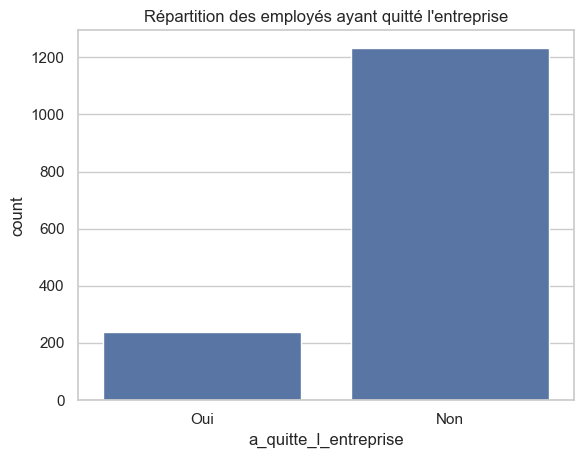

In [28]:
sns.countplot (data=df_central, x="a_quitte_l_entreprise")
plt.title ("Répartition des employés ayant quitté l'entreprise")
plt.show ( )

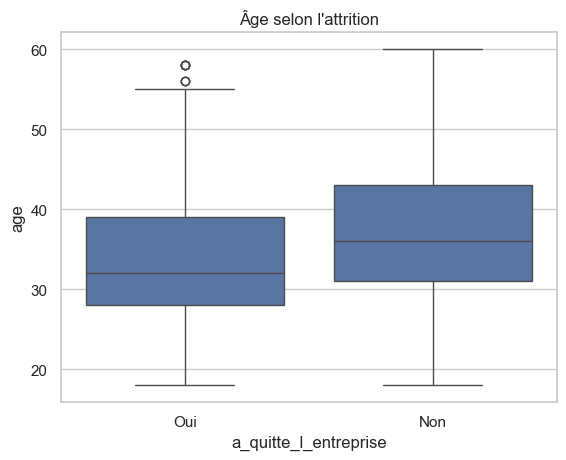

In [29]:
sns.boxplot (data=df_central, x="a_quitte_l_entreprise", y="age")
plt.title ("Âge selon l'attrition")
plt.show ( )

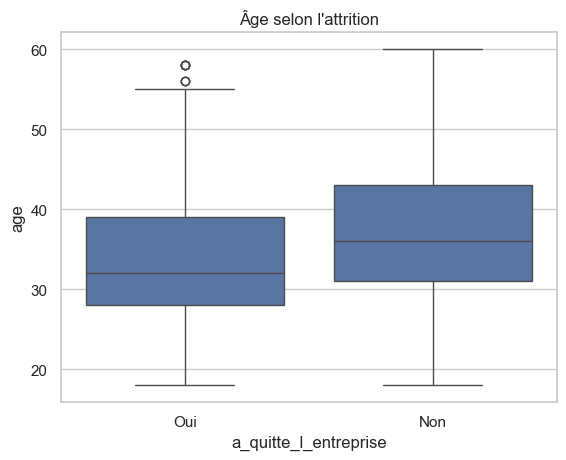

In [30]:
sns.boxplot (data=df_central, x="a_quitte_l_entreprise", y="age")
plt.title ("Âge selon l'attrition")
plt.show ( )

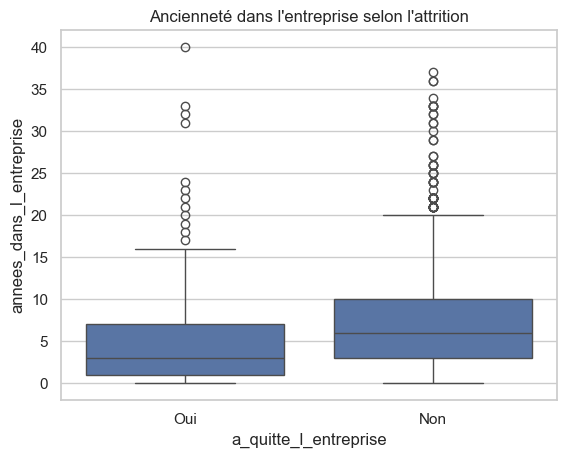

In [31]:
sns.boxplot (data=df_central, x="a_quitte_l_entreprise", y="annees_dans_l_entreprise")
plt.title ("Ancienneté dans l'entreprise selon l'attrition")
plt.show ( )

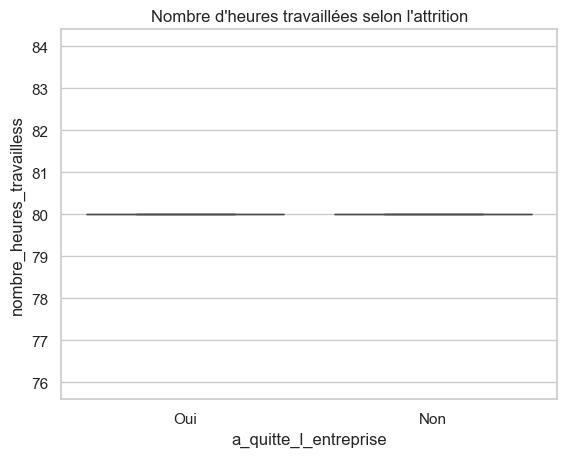

In [32]:
sns.boxplot (data=df_central, x="a_quitte_l_entreprise", y="nombre_heures_travailless")
plt.title ("Nombre d'heures travaillées selon l'attrition")
plt.show ( )

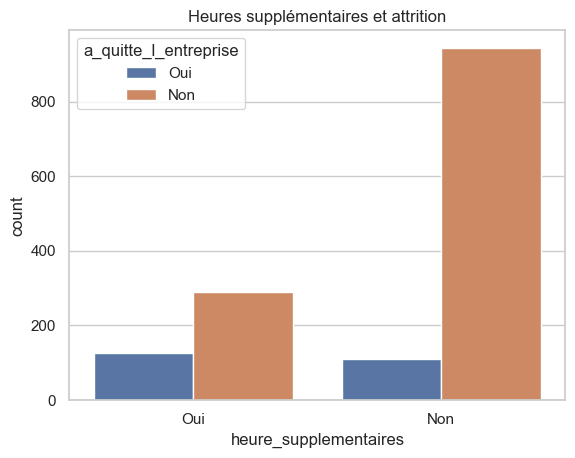

In [33]:
if "heure_supplementaires" in df_central.columns:
    sns.countplot (data=df_central, x="heure_supplementaires", hue="a_quitte_l_entreprise")
    plt.title ("Heures supplémentaires et attrition")
    plt.show ( )

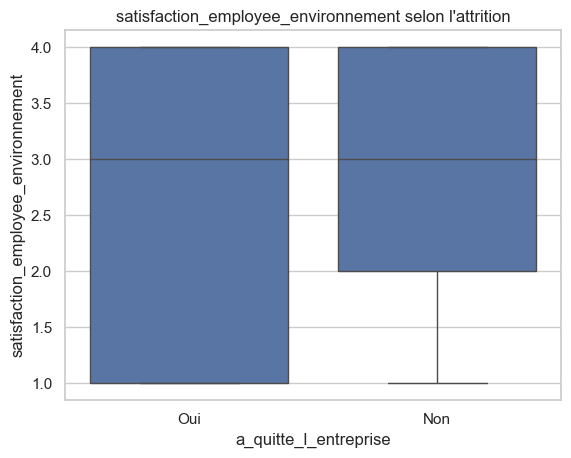

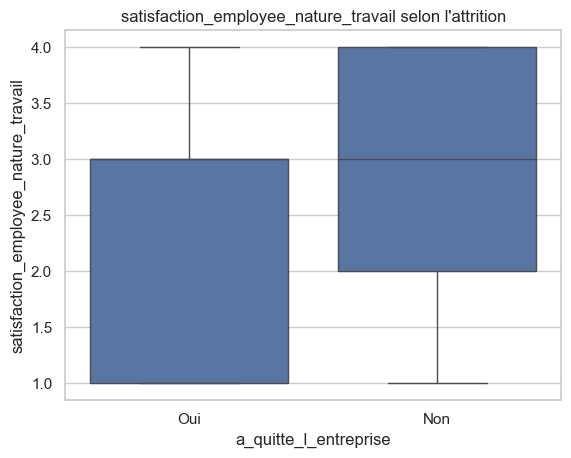

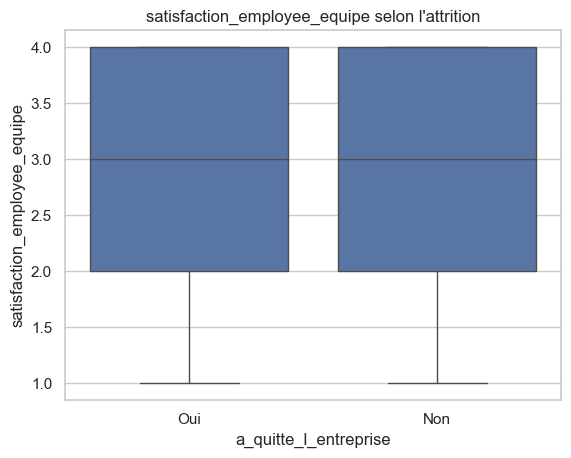

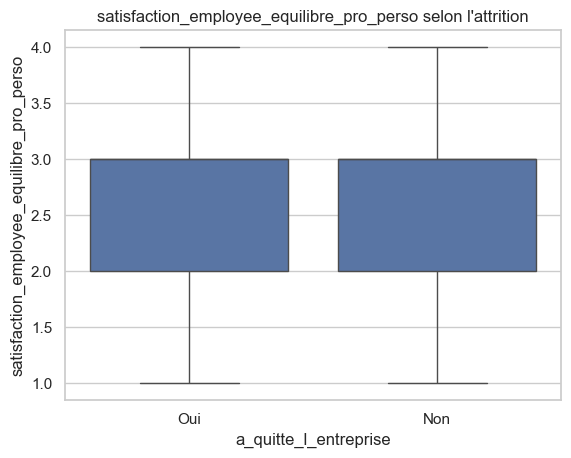

In [34]:
satisfaction_cols = [
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
]

for col in satisfaction_cols:
    if col in df_central.columns:
        sns.boxplot (data=df_central, x="a_quitte_l_entreprise", y=col)
        plt.title (f"{col} selon l'attrition")
        plt.show ( )

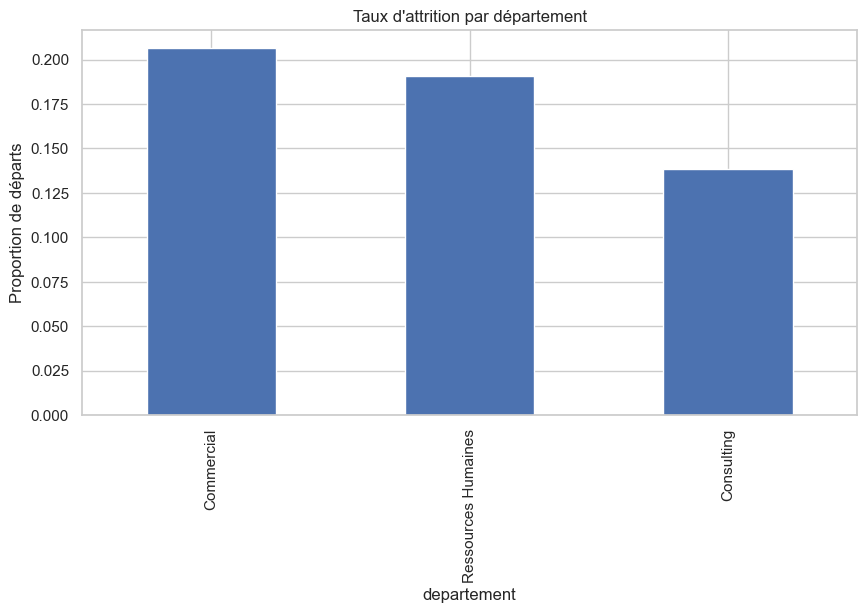

In [35]:
attrition_by_dep = pd.crosstab (
    df_central["departement"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
)

if "Oui" in attrition_by_dep.columns:
    attrition_by_dep["Oui"].sort_values (ascending=False).plot (kind="bar", figsize=(10, 5))
    plt.title ("Taux d'attrition par département")
    plt.ylabel ("Proportion de départs")
    plt.show ( )

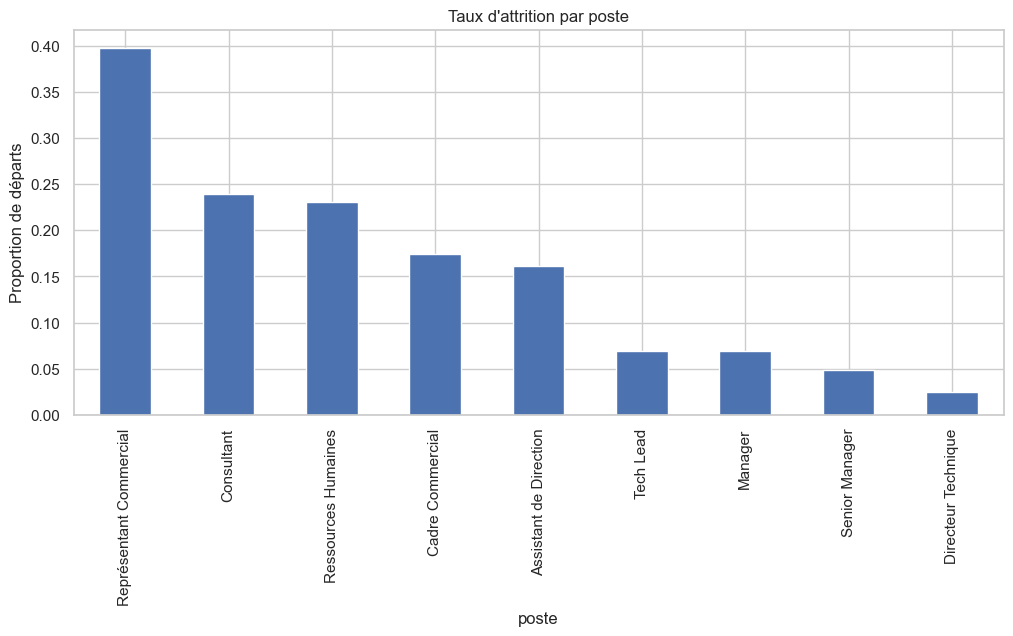

In [36]:
attrition_by_poste = pd.crosstab (
    df_central["poste"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
)

if "Oui" in attrition_by_poste.columns:
    attrition_by_poste["Oui"].sort_values (ascending=False).plot (kind="bar", figsize=(12, 5))
    plt.title ("Taux d'attrition par poste")
    plt.ylabel ("Proportion de départs")
    plt.show ( )

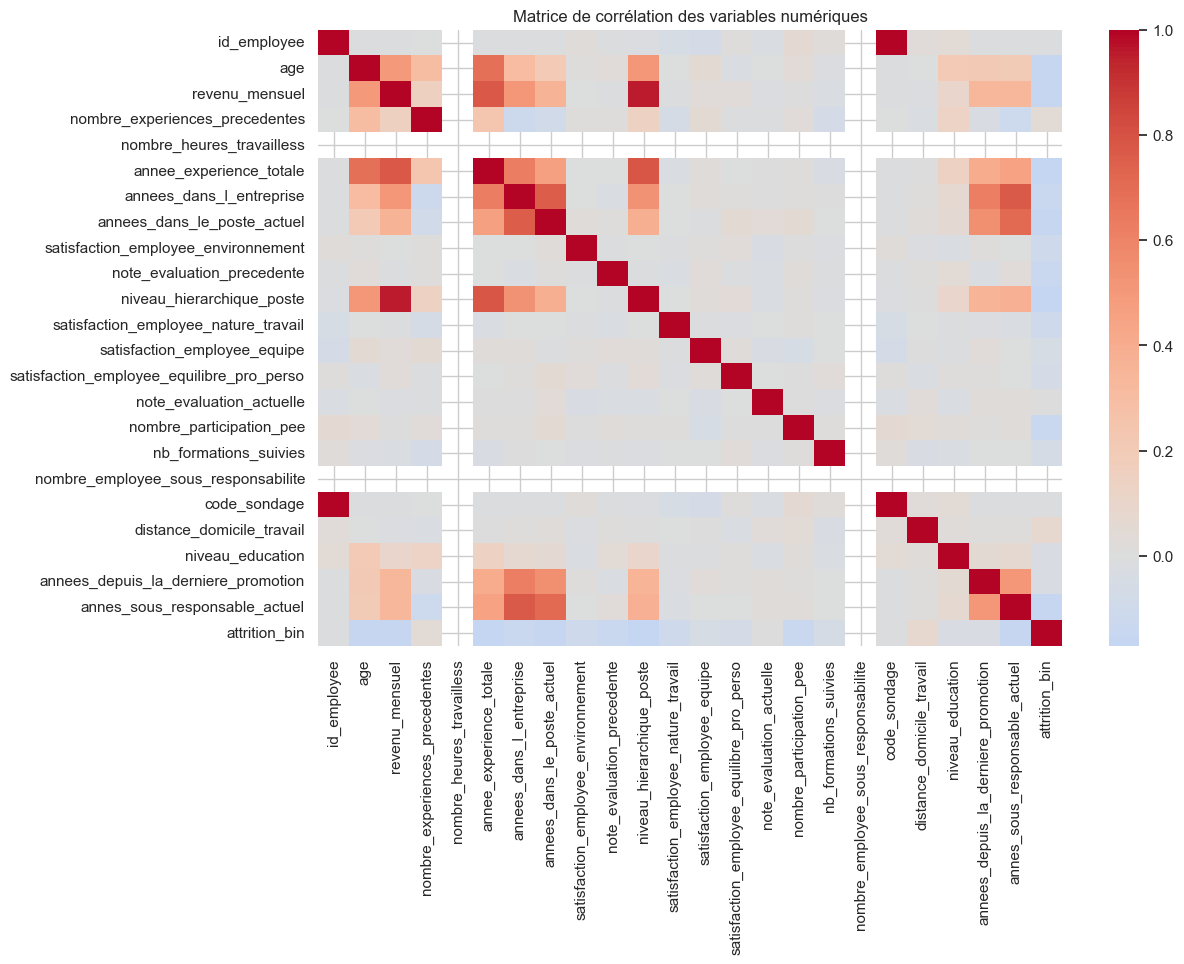

In [37]:
plt.figure (figsize=(12, 8))
corr = df_central[num_cols].corr (numeric_only=True)
sns.heatmap (corr, cmap="coolwarm", center=0)
plt.title ("Matrice de corrélation des variables numériques")
plt.show ( )

In [38]:
cols_for_corr = [col for col in num_cols if col != "attrition_bin"] + ["attrition_bin"]

corr_target = (
    df_central[cols_for_corr]
    .corr(numeric_only=True)["attrition_bin"]
    .sort_values(ascending=False)
)

display(corr_target)

attrition_bin                                1.000000
distance_domicile_travail                    0.077924
nombre_experiences_precedentes               0.043494
note_evaluation_actuelle                     0.002889
code_sondage                                -0.010577
id_employee                                 -0.010577
niveau_education                            -0.031373
annees_depuis_la_derniere_promotion         -0.033019
satisfaction_employee_equipe                -0.045872
nb_formations_suivies                       -0.059478
satisfaction_employee_equilibre_pro_perso   -0.063939
satisfaction_employee_environnement         -0.103369
satisfaction_employee_nature_travail        -0.103481
note_evaluation_precedente                  -0.130016
annees_dans_l_entreprise                    -0.134392
nombre_participation_pee                    -0.137145
annes_sous_responsable_actuel               -0.156199
age                                         -0.159205
revenu_mensuel              

In [39]:
display(corr_target.drop("attrition_bin"))

distance_domicile_travail                    0.077924
nombre_experiences_precedentes               0.043494
note_evaluation_actuelle                     0.002889
code_sondage                                -0.010577
id_employee                                 -0.010577
niveau_education                            -0.031373
annees_depuis_la_derniere_promotion         -0.033019
satisfaction_employee_equipe                -0.045872
nb_formations_suivies                       -0.059478
satisfaction_employee_equilibre_pro_perso   -0.063939
satisfaction_employee_environnement         -0.103369
satisfaction_employee_nature_travail        -0.103481
note_evaluation_precedente                  -0.130016
annees_dans_l_entreprise                    -0.134392
nombre_participation_pee                    -0.137145
annes_sous_responsable_actuel               -0.156199
age                                         -0.159205
revenu_mensuel                              -0.159840
annees_dans_le_poste_actuel 